# E012 — Live (campaign, genre) correction: graduation and adaptation from outcomes

**Hypotheses:** H12 ([docs/hypotheses.md](../../docs/hypotheses.md))

**Question:** Can one online component answer the two open halves of the brief, a rule for when a cold entity has graduated and an adaptation layer that follows outcomes, without hurting CTR?

**Method:** A Gamma-Poisson posterior per (campaign, genre) on a multiplier of the model's pCTR, learned from logged outcomes in strictly earlier hours and replayed over the reconstructed candidate sets of E006. Selection on the validation day by the E008 non-inferiority rule (95 % lower bound of the DR CTR change vs greedy clears -0.2 pp, best point estimate among deterministic configurations), one read of test.

In [1]:
from charade.analysis.experiment import setup

ctx = setup()
f"mode: {'smoke (fixture, tiny model)' if ctx.smoke else 'full data'}"

'mode: full data'

In [2]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import Markdown

from charade.analysis import correction
from charade.analysis.experiment import ensure_bundle

ensure_bundle(ctx)
tables = correction.run(
    ctx.settings,
    ctx.data_dir,
    ctx.reports / "policy" / "correction.md",
    ctx.reports / "coldstart" / "graduation.csv",
    priors=(20.0,) if ctx.smoke else correction.PRIORS,
)
Markdown((ctx.reports / "policy" / "correction.md").read_text())

# Live (campaign, genre) correction (generated by `uv run poe correction`)

Gamma-Poisson posterior on a pCTR multiplier per (campaign, genre), learned from logged outcomes in strictly earlier hours; greedy on the corrected score (z = 0) or on mean + z sd. DR with the independent reward model; log loss compares corrected vs raw pCTR on the ad actually shown. Each split starts from empty sums.

Selection on validation (pre-registered, 95 % lower bound of the DR change vs greedy >= -0.2 pp, best point estimate among z = 0): prior = 80.0, half-life = none.

## Validation (130,142 evaluated impressions)

| prior | half_life_h | z | dr_delta_vs_greedy_pp | ci_low_pp | ci_high_pp | logloss_adj_minus_model | ll_ci_low | ll_ci_high | ne_model | ne_adj | pred_obs_model_cold | pred_obs_adj_cold | graduated_share_last_hour | cohort_dominance | cohort_hhi | repeat_exposure |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 5.0000 | 12.0000 | 0.0000 | -0.0812 | -0.9622 | 0.7974 | 0.0005 | -0.0001 | 0.0010 | 0.8656 | 0.8668 | 0.9339 | 0.9859 | 0.7985 | 0.0754 | 0.0329 | 0.0861 |
| 5.0000 | 12.0000 | 1.0000 | 0.4136 | -0.7304 | 1.3866 | 0.0005 | -0.0001 | 0.0010 | 0.8656 | 0.8668 | 0.9339 | 0.9859 | 0.7985 | 0.0668 | 0.0275 | 0.0836 |
| 5.0000 | 48.0000 | 0.0000 | -0.2609 | -1.0767 | 0.5908 | 0.0007 | 0.0001 | 0.0013 | 0.8656 | 0.8673 | 0.9339 | 0.9865 | 0.8561 | 0.0765 | 0.0331 | 0.0845 |
| 5.0000 | 48.0000 | 1.0000 | 0.6696 | -0.5423 | 1.6639 | 0.0007 | 0.0001 | 0.0013 | 0.8656 | 0.8673 | 0.9339 | 0.9865 | 0.8561 | 0.0681 | 0.0276 | 0.0828 |
| 5.0000 | inf | 0.0000 | -0.1504 | -0.9830 | 0.7142 | 0.0008 | 0.0002 | 0.0014 | 0.8656 | 0.8675 | 0.9339 | 0.9867 | 0.8703 | 0.0768 | 0.0331 | 0.0841 |
| 5.0000 | inf | 1.0000 | 0.7069 | -0.4432 | 1.6575 | 0.0008 | 0.0002 | 0.0014 | 0.8656 | 0.8675 | 0.9339 | 0.9867 | 0.8703 | 0.0685 | 0.0277 | 0.0827 |
| 20.0000 | 12.0000 | 0.0000 | 0.4589 | -0.2880 | 1.2020 | -0.0006 | -0.0010 | -0.0003 | 0.8656 | 0.8643 | 0.9339 | 0.9679 | 0.4535 | 0.0787 | 0.0347 | 0.0931 |
| 20.0000 | 12.0000 | 1.0000 | 0.5477 | -0.2205 | 1.2598 | -0.0006 | -0.0010 | -0.0003 | 0.8656 | 0.8643 | 0.9339 | 0.9679 | 0.4535 | 0.0724 | 0.0313 | 0.0899 |
| 20.0000 | 48.0000 | 0.0000 | 0.5407 | -0.1604 | 1.2472 | -0.0005 | -0.0009 | -0.0002 | 0.8656 | 0.8645 | 0.9339 | 0.9687 | 0.5544 | 0.0808 | 0.0351 | 0.0921 |
| 20.0000 | 48.0000 | 1.0000 | 0.7724 | -0.0531 | 1.5362 | -0.0005 | -0.0009 | -0.0002 | 0.8656 | 0.8645 | 0.9339 | 0.9687 | 0.5544 | 0.0740 | 0.0315 | 0.0890 |
| 20.0000 | inf | 0.0000 | 0.5003 | -0.2249 | 1.2466 | -0.0005 | -0.0009 | -0.0002 | 0.8656 | 0.8645 | 0.9339 | 0.9690 | 0.6128 | 0.0813 | 0.0352 | 0.0916 |
| 20.0000 | inf | 1.0000 | 0.7465 | -0.1148 | 1.5600 | -0.0005 | -0.0009 | -0.0002 | 0.8656 | 0.8645 | 0.9339 | 0.9690 | 0.6128 | 0.0745 | 0.0315 | 0.0887 |
| 80.0000 | 12.0000 | 0.0000 | 0.5345 | -0.0591 | 1.1309 | -0.0005 | -0.0007 | -0.0004 | 0.8656 | 0.8645 | 0.9339 | 0.9501 | 0.0552 | 0.0782 | 0.0351 | 0.0958 |
| 80.0000 | 12.0000 | 1.0000 | 0.8173 | 0.1005 | 1.4436 | -0.0005 | -0.0007 | -0.0004 | 0.8656 | 0.8645 | 0.9339 | 0.9501 | 0.0552 | 0.0746 | 0.0339 | 0.0950 |
| 80.0000 | 48.0000 | 0.0000 | 0.5289 | -0.1560 | 1.2003 | -0.0006 | -0.0008 | -0.0004 | 0.8656 | 0.8644 | 0.9339 | 0.9509 | 0.1349 | 0.0792 | 0.0354 | 0.0955 |
| 80.0000 | 48.0000 | 1.0000 | 0.8040 | 0.0572 | 1.4490 | -0.0006 | -0.0008 | -0.0004 | 0.8656 | 0.8644 | 0.9339 | 0.9509 | 0.1349 | 0.0755 | 0.0339 | 0.0946 |
| 80.0000 | inf | 0.0000 | 0.5484 | -0.1558 | 1.2467 | -0.0006 | -0.0008 | -0.0004 | 0.8656 | 0.8644 | 0.9339 | 0.9512 | 0.1581 | 0.0800 | 0.0355 | 0.0954 |
| 80.0000 | inf | 1.0000 | 0.8293 | 0.0681 | 1.4777 | -0.0006 | -0.0008 | -0.0004 | 0.8656 | 0.8644 | 0.9339 | 0.9512 | 0.1581 | 0.0763 | 0.0340 | 0.0943 |
| 320.0000 | 12.0000 | 0.0000 | 0.2648 | -0.1505 | 0.6520 | -0.0002 | -0.0003 | -0.0002 | 0.8656 | 0.8652 | 0.9339 | 0.9395 | 0.0000 | 0.0831 | 0.0357 | 0.0975 |
| 320.0000 | 12.0000 | 1.0000 | 0.2132 | -0.2154 | 0.6413 | -0.0002 | -0.0003 | -0.0002 | 0.8656 | 0.8652 | 0.9339 | 0.9395 | 0.0000 | 0.0812 | 0.0353 | 0.0975 |
| 320.0000 | 48.0000 | 0.0000 | 0.2911 | -0.1282 | 0.6999 | -0.0003 | -0.0003 | -0.0002 | 0.8656 | 0.8651 | 0.9339 | 0.9399 | 0.0000 | 0.0829 | 0.0356 | 0.0973 |
| 320.0000 | 48.0000 | 1.0000 | 0.3033 | -0.1178 | 0.6961 | -0.0003 | -0.0003 | -0.0002 | 0.8656 | 0.8651 | 0.9339 | 0.9399 | 0.0000 | 0.0811 | 0.0351 | 0.0971 |
| 320.0000 | inf | 0.0000 | 0.2877 | -0.1068 | 0.6964 | -0.0003 | -0.0004 | -0.0002 | 0.8656 | 0.8650 | 0.9339 | 0.9400 | 0.0000 | 0.0828 | 0.0355 | 0.0971 |
| 320.0000 | inf | 1.0000 | 0.2871 | -0.1604 | 0.7270 | -0.0003 | -0.0004 | -0.0002 | 0.8656 | 0.8650 | 0.9339 | 0.9400 | 0.0000 | 0.0809 | 0.0351 | 0.0970 |

## Test (111,368 evaluated impressions, read once)

| prior | half_life_h | z | dr_delta_vs_greedy_pp | ci_low_pp | ci_high_pp | logloss_adj_minus_model | ll_ci_low | ll_ci_high | ne_model | ne_adj | pred_obs_model_cold | pred_obs_adj_cold | graduated_share_last_hour | cohort_dominance | cohort_hhi | repeat_exposure |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 5.0000 | 12.0000 | 0.0000 | 0.5626 | -0.5852 | 1.6639 | 0.0003 | -0.0009 | 0.0015 | 0.8842 | 0.8849 | 0.9366 | 0.9841 | 0.8738 | 0.0821 | 0.0282 | 0.0880 |
| 5.0000 | 12.0000 | 1.0000 | 0.5777 | -0.6059 | 1.6915 | 0.0003 | -0.0009 | 0.0015 | 0.8842 | 0.8849 | 0.9366 | 0.9841 | 0.8738 | 0.0685 | 0.0239 | 0.0849 |
| 5.0000 | 48.0000 | 0.0000 | 0.7994 | -0.1901 | 1.7900 | 0.0007 | -0.0006 | 0.0020 | 0.8842 | 0.8857 | 0.9366 | 0.9887 | 0.9218 | 0.0873 | 0.0292 | 0.0877 |
| 5.0000 | 48.0000 | 1.0000 | 0.5707 | -0.5415 | 1.6204 | 0.0007 | -0.0006 | 0.0020 | 0.8842 | 0.8857 | 0.9366 | 0.9887 | 0.9218 | 0.0711 | 0.0245 | 0.0843 |
| 5.0000 | inf | 0.0000 | 0.9022 | -0.2305 | 2.0314 | 0.0008 | -0.0004 | 0.0022 | 0.8842 | 0.8860 | 0.9366 | 0.9903 | 0.9312 | 0.0882 | 0.0295 | 0.0877 |
| 5.0000 | inf | 1.0000 | 0.5465 | -0.6116 | 1.6264 | 0.0008 | -0.0004 | 0.0022 | 0.8842 | 0.8860 | 0.9366 | 0.9903 | 0.9312 | 0.0728 | 0.0248 | 0.0843 |
| 20.0000 | 12.0000 | 0.0000 | 0.4584 | -0.2894 | 1.1890 | -0.0008 | -0.0014 | -0.0001 | 0.8842 | 0.8826 | 0.9366 | 0.9624 | 0.6011 | 0.0732 | 0.0275 | 0.0938 |
| 20.0000 | 12.0000 | 1.0000 | 0.3426 | -0.2966 | 1.0761 | -0.0008 | -0.0014 | -0.0001 | 0.8842 | 0.8826 | 0.9366 | 0.9624 | 0.6011 | 0.0708 | 0.0261 | 0.0940 |
| 20.0000 | 48.0000 | 0.0000 | 0.6934 | -0.2668 | 1.5642 | -0.0006 | -0.0014 | 0.0001 | 0.8842 | 0.8829 | 0.9366 | 0.9669 | 0.7744 | 0.0777 | 0.0283 | 0.0933 |
| 20.0000 | 48.0000 | 1.0000 | 0.7494 | -0.1635 | 1.6755 | -0.0006 | -0.0014 | 0.0001 | 0.8842 | 0.8829 | 0.9366 | 0.9669 | 0.7744 | 0.0736 | 0.0266 | 0.0933 |
| 20.0000 | inf | 0.0000 | 0.5495 | -0.4344 | 1.4648 | -0.0006 | -0.0014 | 0.0002 | 0.8842 | 0.8830 | 0.9366 | 0.9687 | 0.8093 | 0.0794 | 0.0285 | 0.0932 |
| 20.0000 | inf | 1.0000 | 0.6157 | -0.3736 | 1.5600 | -0.0006 | -0.0014 | 0.0002 | 0.8842 | 0.8830 | 0.9366 | 0.9687 | 0.8093 | 0.0744 | 0.0268 | 0.0930 |
| 80.0000 | 12.0000 | 0.0000 | 0.4471 | -0.0840 | 0.9419 | -0.0005 | -0.0008 | -0.0003 | 0.8842 | 0.8831 | 0.9366 | 0.9469 | 0.0918 | 0.0760 | 0.0276 | 0.0989 |
| 80.0000 | 12.0000 | 1.0000 | 0.4088 | -0.1467 | 0.8974 | -0.0005 | -0.0008 | -0.0003 | 0.8842 | 0.8831 | 0.9366 | 0.9469 | 0.0918 | 0.0756 | 0.0271 | 0.0992 |
| 80.0000 | 48.0000 | 0.0000 | 0.3986 | -0.1130 | 0.8622 | -0.0005 | -0.0008 | -0.0002 | 0.8842 | 0.8831 | 0.9366 | 0.9498 | 0.1202 | 0.0759 | 0.0275 | 0.0987 |
| 80.0000 | 48.0000 | 1.0000 | 0.3876 | -0.1132 | 0.8187 | -0.0005 | -0.0008 | -0.0002 | 0.8842 | 0.8831 | 0.9366 | 0.9498 | 0.1202 | 0.0753 | 0.0270 | 0.0988 |
| 80.0000 | inf | 0.0000 | 0.4932 | -0.0654 | 1.0190 | -0.0005 | -0.0009 | -0.0002 | 0.8842 | 0.8831 | 0.9366 | 0.9510 | 0.2281 | 0.0758 | 0.0275 | 0.0984 |
| 80.0000 | inf | 1.0000 | 0.4634 | -0.0872 | 0.9440 | -0.0005 | -0.0009 | -0.0002 | 0.8842 | 0.8831 | 0.9366 | 0.9510 | 0.2281 | 0.0749 | 0.0270 | 0.0984 |
| 320.0000 | 12.0000 | 0.0000 | 0.1717 | -0.0875 | 0.4509 | -0.0002 | -0.0003 | -0.0001 | 0.8842 | 0.8838 | 0.9366 | 0.9397 | 0.0000 | 0.0813 | 0.0287 | 0.1016 |
| 320.0000 | 12.0000 | 1.0000 | 0.1727 | -0.0843 | 0.4439 | -0.0002 | -0.0003 | -0.0001 | 0.8842 | 0.8838 | 0.9366 | 0.9397 | 0.0000 | 0.0810 | 0.0286 | 0.1016 |
| 320.0000 | 48.0000 | 0.0000 | 0.2584 | 0.0016 | 0.5439 | -0.0002 | -0.0003 | -0.0001 | 0.8842 | 0.8838 | 0.9366 | 0.9409 | 0.0000 | 0.0808 | 0.0286 | 0.1012 |
| 320.0000 | 48.0000 | 1.0000 | 0.1819 | -0.0645 | 0.4872 | -0.0002 | -0.0003 | -0.0001 | 0.8842 | 0.8838 | 0.9366 | 0.9409 | 0.0000 | 0.0805 | 0.0284 | 0.1012 |
| 320.0000 | inf | 0.0000 | 0.3342 | 0.0192 | 0.7071 | -0.0002 | -0.0003 | -0.0001 | 0.8842 | 0.8837 | 0.9366 | 0.9414 | 0.0000 | 0.0806 | 0.0285 | 0.1012 |
| 320.0000 | inf | 1.0000 | 0.2822 | -0.0120 | 0.6211 | -0.0002 | -0.0003 | -0.0001 | 0.8842 | 0.8837 | 0.9366 | 0.9414 | 0.0000 | 0.0803 | 0.0283 | 0.1011 |


## Deterministic configurations, validation then test

Positive `dr_delta_vs_greedy_pp` is a CTR gain; negative `logloss_adj_minus_model` means the corrected pCTR predicts the logged ad's click better than the raw one.

In [3]:
columns = [
    "prior",
    "half_life_h",
    "dr_delta_vs_greedy_pp",
    "ci_low_pp",
    "ci_high_pp",
    "logloss_adj_minus_model",
    "ll_ci_low",
    "ll_ci_high",
    "pred_obs_model_cold",
    "pred_obs_adj_cold",
    "graduated_share_last_hour",
    "cohort_hhi",
]
tables["val"].filter(pl.col("z") == 0.0).select(columns)

prior,half_life_h,dr_delta_vs_greedy_pp,ci_low_pp,ci_high_pp,logloss_adj_minus_model,ll_ci_low,ll_ci_high,pred_obs_model_cold,pred_obs_adj_cold,graduated_share_last_hour,cohort_hhi
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
5.0,12.0,-0.081216,-0.962155,0.797422,0.000524,-0.000096,0.001016,0.933854,0.985879,0.798502,0.032889
5.0,48.0,-0.260853,-1.076671,0.590839,0.000744,0.000102,0.001263,0.933854,0.986511,0.856073,0.033103
5.0,inf,-0.15044,-0.982978,0.714242,0.000844,0.000193,0.001368,0.933854,0.986748,0.870268,0.033145
20.0,12.0,0.458915,-0.287996,1.201953,-0.000585,-0.000995,-0.000258,0.933854,0.96785,0.45347,0.034709
20.0,48.0,0.540738,-0.160395,1.2472,-0.00053,-0.000947,-0.000192,0.933854,0.968715,0.554416,0.035136
…,…,…,…,…,…,…,…,…,…,…,…
80.0,48.0,0.528901,-0.155982,1.200312,-0.000553,-0.00076,-0.000381,0.933854,0.950879,0.134858,0.035395
80.0,inf,0.548364,-0.155752,1.246736,-0.000565,-0.000782,-0.000385,0.933854,0.951154,0.158123,0.035509
320.0,12.0,0.264756,-0.150486,0.652036,-0.000221,-0.000284,-0.00017,0.933854,0.939464,0.0,0.035656


In [4]:
tables["test"].filter(pl.col("z") == 0.0).select(columns)

prior,half_life_h,dr_delta_vs_greedy_pp,ci_low_pp,ci_high_pp,logloss_adj_minus_model,ll_ci_low,ll_ci_high,pred_obs_model_cold,pred_obs_adj_cold,graduated_share_last_hour,cohort_hhi
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
5.0,12.0,0.562638,-0.585188,1.663895,0.000285,-0.000883,0.001503,0.936589,0.984143,0.873832,0.028177
5.0,48.0,0.799356,-0.190064,1.789991,0.00067,-0.000573,0.001971,0.936589,0.988672,0.921835,0.029248
5.0,inf,0.902207,-0.230473,2.031432,0.000832,-0.000428,0.002178,0.936589,0.990343,0.931181,0.029469
20.0,12.0,0.458387,-0.289381,1.189014,-0.000755,-0.001428,-0.000129,0.936589,0.962371,0.601105,0.027536
20.0,48.0,0.6934,-0.266836,1.564183,-0.000623,-0.001413,0.000101,0.936589,0.966943,0.774427,0.028287
…,…,…,…,…,…,…,…,…,…,…,…
80.0,48.0,0.398637,-0.113043,0.862153,-0.000538,-0.00085,-0.00025,0.936589,0.949793,0.120221,0.027486
80.0,inf,0.493236,-0.065386,1.019045,-0.000536,-0.000873,-0.000217,0.936589,0.951006,0.228122,0.027542
320.0,12.0,0.171735,-0.087529,0.45093,-0.00019,-0.000268,-0.000121,0.936589,0.939706,0.0,0.028732


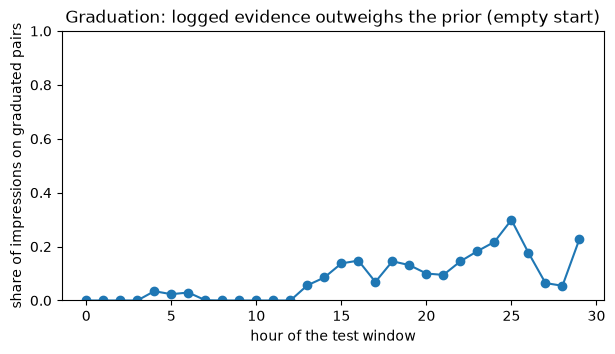

In [5]:
curve = tables["graduation"]
if curve.height:
    _, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(range(curve.height), curve["graduated"], "o-")
    ax.set(xlabel="hour of the test window", ylabel="share of impressions on graduated pairs", ylim=(0, 1))
    ax.set_title("Graduation: logged evidence outweighs the prior (empty start)")
    plt.show()

## Reading
- The prior strength sets the trade-off. A weak prior (5 expected clicks) corrects cold campaigns almost fully but hurts the logged-ad log loss on validation; a strong one (320) is safe and nearly inert. Between 20 and 80 both readings improve.
- The log-loss reading is causal and online: it compares two predictions for the same shown ad using only earlier hours. It does not rest on reconstructed candidate sets or frequency-share propensities.
- Half-life cannot be distinguished on a 30-hour window; the decay exists for drift at week scale.
- Each split starts from empty sums, so graduation shares understate production, where the state carries over.
- The replay learns from the logging traffic, not from the corrected policy's own choices; an online test remains the arbiter, as for the exposure penalty.

## Conclusion
Selected on validation (prior 80 expected clicks, no decay), the corrected greedy policy is non-inferior to greedy pCTR on test at the 0.2 pp margin with a positive point estimate, lowers the log loss of the shown ad with a CI excluding zero, and narrows the cold-campaign under-prediction. Graduation is defined: a (campaign, genre) pair has graduated once its logged expected clicks reach the prior. Half-life is indistinguishable on 30 hours. Numbers: the test table above and [reports/policy/correction.md](../../reports/policy/correction.md).

**Decision:** Ship the correction in the policy with the selected prior and no decay, replacing the frozen training-count evidence table; graduation = logged expected clicks ≥ prior. The CTR point estimate awaits the same online test as the exposure penalty.